In [16]:
#### take a filename and run quot on it
from quot.core import track_file
import init_settings
import trackingCodeFunctions
import plotFunctions

from init_settings import *
from trackingCodeFunctions import *
from plotFunctions import *


import os
import subprocess

import pickle

import pims
from collections import defaultdict
import re
import time
import yaml
import shutil

import argparse

import pandas as pd
import numpy as np

In [17]:
directory_to_analyze = '/lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/'

In [18]:
settings = init_settings.get_default_settings()

override_file = 'settings_override.yaml'
override_path = os.path.join(directory_to_analyze , override_file)
if os.path.exists(override_path):
    with open(override_path) as f:
        override_cfg = yaml.load(f, Loader=yaml.FullLoader)
    trackingCodeFunctions.deep_update(settings, override_cfg)
settings = init_settings.update_default_settings_for_analysis(settings , directory_to_analyze)
####

####
### dump settings file and print settings to stdout
pkl_path = os.path.join(settings['io']['analysis_directory'] , "settings.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(settings, f)

txt_path = os.path.join(settings['io']['analysis_directory'] , "settings.txt")
print('')
#print_nested_dict(settings)
trackingCodeFunctions.print_nested_dict(settings , file = txt_path)
print('')
####

####
data_dir = os.path.join(settings['io']['home_directory'] , settings['io']['data_filepath'])
#grouped_files = trackingCodeFunctions.group_files_by_metadata(data_dir) ## NOTE FILE NAMING CONVENTIONS ARE NOT VERY FLEXIBLE


In [4]:
nd2_files = trackingCodeFunctions.identify_missing_filewise(settings , force = True)
print(nd2_files)

{'send=cGS201_rec=cGS572_exp=0p006': ['send=cGS201_rec=cGS572_exp=0p006_002.nd2', 'send=cGS201_rec=cGS572_exp=0p006_003.nd2'], 'send=cGS205_rec=cGS572_exp=0p006': ['send=cGS205_rec=cGS572_exp=0p006_028.nd2', 'send=cGS205_rec=cGS572_exp=0p006_029.nd2']}


In [6]:
nd2_files = identify_missing_filewise(settings , force = False)

filewise_script = os.path.join(settings['io']['code_directory'], 'call_filewise_operations.slurm')
conditionwise_script = os.path.join(settings['io']['code_directory'], 'call_conditionwise_operations.slurm')

# Dictionary to hold submitted job array IDs per condition
job_ids_by_condition = {}
for cond, fileList in nd2_files.items():
    fileList_string = ":".join(os.path.join(settings['io']['data_directory'], f) for f in fileList)
    
    # Submit the job array
    result = subprocess.run([
        "sbatch",
        f"--array=0-{len(fileList)-1}",
        '--parsable',  # Returns only the job ID
        '--export', f"ITEM_STRING={fileList_string},PKL_PATH={pkl_path},CONDITION={cond},CODE_DIRECTORY={settings['io']['code_directory']}",
        filewise_script
    ], capture_output=True, text=True)

    job_id = result.stdout.strip()  # SLURM job ID of the array
    job_ids_by_condition[cond] = job_id
    print(f"Submitted array for condition {cond}, Job ID: {job_id}")

print('')

## if there were no files previously run, go head and pull the conditions with empty dependencies associated
if not job_ids_by_condition:
    job_ids_by_condition = identify_missing_filewise(settings , force = True)
    for key in job_ids_by_condition:
        job_ids_by_condition[key] = 0

# Now submit the "next step" jobs that depend on each array finishing
for cond, array_job_id in job_ids_by_condition.items():
    # The dependency string for SLURM: all jobs in array must finish
    dependency_string = f"afterok:{array_job_id}"
    
    if array_job_id == 0:
        job_string = [
            "sbatch",
            "--export", f"CONDITION={cond},PKL_PATH={pkl_path},CODE_DIRECTORY={settings['io']['code_directory']}",
            conditionwise_script
        ]
    else:
        job_string = [
            "sbatch",
            f"--dependency={dependency_string}",
            "--export", f"CONDITION={cond},PKL_PATH={pkl_path},CODE_DIRECTORY={settings['io']['code_directory']}",
            conditionwise_script
        ]
    
    result_next = subprocess.run(job_string, capture_output=True, text=True)

    if result_next.returncode != 0:
        print(f"Error submitting job for {cond}:")
        print(result_next.stderr)
    else:
        print(f"Submitted next step for {cond}, dependent on array {array_job_id}")
        print(result_next.stdout)



Missing files:
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=30p0/trajectories/send=cGS201_rec=cGS572_exp=0p006_002_traj.csv
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=30p0/posterior/send=cGS201_rec=cGS572_exp=0p006_002_posterior.csv
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=30p0/MLE/send=cGS201_rec=cGS572_exp=0p006_002_MLE.csv
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=30p0/rolling_windows/send=cGS201_rec=cGS572_exp=0p006_002_rollingMLE.csv
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=30p0/trajectories/send=cGS201_rec=cGS572_exp=0p006_003_traj.csv
  send=cGS201_rec=cGS572_exp=0p006: /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tra

In [19]:
cond = 'send=cGS201_rec=cGS572_exp=0p006'

In [20]:
posterior_df = trackingCodeFunctions.aggregate_csv(settings['io']['post_directory'] , f"{cond}*.csv")
posterior_df['condition'] = [re.sub("_[0-9]*_traj.csv$" , '' , f) for f in posterior_df['file']]

MLE_df = trackingCodeFunctions.aggregate_csv(settings['io']['MLE_directory'] , f"{cond}*.csv")
MLE_df['file_basename'] = [os.path.basename(f) for f in MLE_df['source_file']]
MLE_df['condition'] = [re.sub("_[0-9]*_traj.csv$" , '' , f) for f in MLE_df['file_basename']]

rollingMLE = trackingCodeFunctions.aggregate_csv(settings['io']['rolling_window_directory'] , f"{cond}*.csv")
rollingMLE['file_basename'] = [re.sub("::[0-9]*$" , '.csv' , traj) for traj in rollingMLE['ur_trajectory']]
rollingMLE['condition'] = [re.sub("_[0-9]*_traj.csv$" , '' , traj) for traj in rollingMLE['file_basename']]


In [21]:
## clean objects to remove outlier positions
outliers = plotFunctions.find_outlier_filenames(posterior_df)
posterior_df = posterior_df[~posterior_df['file'].isin(outliers)]
MLE_df = MLE_df[~MLE_df['file_basename'].isin(outliers)]
rollingMLE = rollingMLE[~rollingMLE['file_basename'].isin(outliers)]

In [22]:
outliers

[]

In [23]:
## start plotting routines
posterior_plot_df = plotFunctions.generate_posterior_plotting_df(posterior_df)

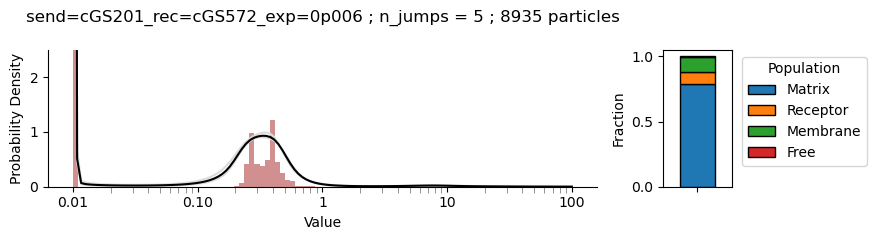

In [24]:
plotFunctions.generate_plots(MLE_df , posterior_plot_df , posterior_df , settings , showPlot = True)

In [25]:
rollingMLE = plotFunctions.fitHMM(rollingMLE , settings , cond , min_obs=7)

## handle the case that slowSPT should cont all data, and not trim ends with nan
if settings['saspt']['frame_interval'] > 1:
    rolling_MLE['posterior_pop'] = 0
    rolling_MLE['naive_pop'] = 0

Running HMM


Model is not converging.  Current: -109364.04430846892 is not greater than -75921.37523236744. Delta is -33442.669076101476


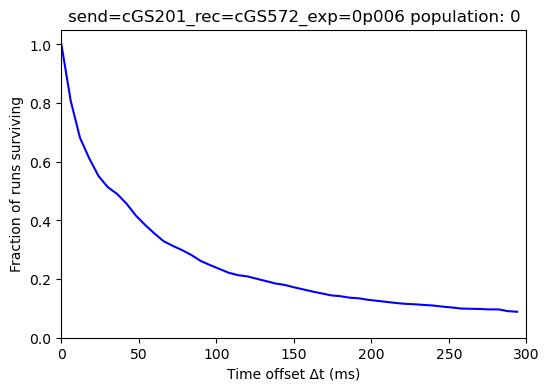

In [26]:
plotFunctions.plot_survival_HMM(rollingMLE , settings , cond , 0 , showPlot = True , min_run = 0)

In [109]:
## save PKL of the files that contain plotting data
plotting_pkl_dir = f"{settings['io']['plot_directory']}/plotting_pkls"
os.makedirs(plotting_pkl_dir, exist_ok=True)

plotting_pkl = f"{settings['io']['plot_directory']}/plotting_pkls/{cond}.pkl"
with open(plotting_pkl, "wb") as f:
   pickle.dump({'MLE_df' : MLE_df , 
                'posterior_plot_df' : posterior_plot_df , 
               'rollingMLE' : rollingMLE}, 
               f)


In [110]:
# Next step -- this block should plot bleaching & output movies
# once it's written, insert it after the pkl save. this block require accessing the underlying data again.

# then go back and re-implement the opportunity to split input images (i.e. for slowSPT)


In [111]:
rollingMLE --> should be easy to plug into existing bleaching code

SyntaxError: invalid syntax (1135208466.py, line 1)

In [12]:
rollingMLE

,y,x,I0,frame,ur_trajectory,MLE_D,file_basename,condition,posterior_pop,naive_pop
0,6.340747,395.986967,1613.979960,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::56,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
1,120.575068,656.711704,401.474586,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::2398,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
2,120.000631,569.204256,463.248498,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::289,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
3,119.967845,110.129103,343.043544,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::96,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
4,117.038666,514.804408,314.394038,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::11,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
48330,236.776200,77.242207,627.860951,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::2403,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
48331,247.391896,44.226450,1162.150995,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::2405,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
48332,250.398852,663.946078,698.296993,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::2410,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
48333,253.280857,59.178448,691.304593,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::2404,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN


In [27]:
min_obs = 7
n_particles = 10

In [28]:
counts = rollingMLE['ur_trajectory'].value_counts()
valid_trajectories = counts[counts >= min_obs].index
rollingMLE_filtered = rollingMLE[rollingMLE['ur_trajectory'].isin(valid_trajectories)].copy()
bc = pd.DataFrame()
prev_open_image = ''

unique_trajs = np.unique(rollingMLE_filtered["ur_trajectory"])
n = min(n_particles, len(unique_trajs))
#n = n_particles
sampled_ids = np.random.choice(unique_trajs, size=n, replace=False)
sampled_ids = sorted(sampled_ids)
sampled_trajs = rollingMLE_filtered[rollingMLE_filtered['ur_trajectory'].isin(sampled_ids)]
sampled_trajs = sampled_trajs.sort_values(by=['ur_trajectory', 'frame'], ignore_index=True)



In [31]:
bc

,y,x,I0,frame,ur_trajectory,MLE_D,file_basename,condition,posterior_pop,naive_pop,og_frame,rel_frame,signal,background
0,269.586151,13.507786,695.766072,47,send=cGS201_rec=cGS572_exp=0p006_002_traj::1059,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,47.0,-29,134.777778,117.0
1,269.578794,13.698437,697.527764,48,send=cGS201_rec=cGS572_exp=0p006_002_traj::1059,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,48.0,-28,133.666667,117.0
2,269.484537,13.062847,595.740111,49,send=cGS201_rec=cGS572_exp=0p006_002_traj::1059,0.010000,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,0.0,0.0,49.0,-27,133.333333,117.0
3,268.935484,13.237535,554.007520,50,send=cGS201_rec=cGS572_exp=0p006_002_traj::1059,0.304699,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,3.0,1.0,50.0,-26,129.666667,119.0
4,268.895680,12.443838,635.396491,51,send=cGS201_rec=cGS572_exp=0p006_002_traj::1059,0.304699,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,2.0,1.0,51.0,-25,130.777778,118.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,133.750505,246.829567,NaN,69,send=cGS201_rec=cGS572_exp=0p006_003_traj::561,NaN,NaN,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,NaN,6,111.444444,109.0
16,133.750505,246.829567,NaN,70,send=cGS201_rec=cGS572_exp=0p006_003_traj::561,NaN,NaN,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,NaN,7,108.444444,109.0
17,133.750505,246.829567,NaN,71,send=cGS201_rec=cGS572_exp=0p006_003_traj::561,NaN,NaN,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,NaN,8,114.777778,110.0
18,133.750505,246.829567,NaN,72,send=cGS201_rec=cGS572_exp=0p006_003_traj::561,NaN,NaN,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN,NaN,9,112.000000,110.0


In [30]:
# iterate over each sampled trajectory and run your code
for traj_id in sampled_ids:
    this_traj , boundingBox = isolate_traj(rollingMLE_filtered , traj_id)

   # try:
    file_pattern = this_traj['ur_trajectory'].replace(r'_traj::\d+', '.nd2', regex=True)[0]
    image_file = glob.glob(os.path.join(settings['io']['data_directory'] , file_pattern))[0]

    ## only reload the image if neccessary
    if image_file == prev_open_image:
        pass
        #print('skipping open new image')
    else:
        #print(f'Old image:: {prev_open_image} ... new image:: {image_file}')
        img = pims.open(image_file)
        img_stack = np.array(img)
        prev_open_image = image_file                
    bc = pd.concat([bc , bleaching_curve(img , this_traj)])

    #except:
    #    print('Caught an error')
    #    pass


In [ ]:
def aggregate_bleaching_data(rollingMLE , n_particles = 200 , min_obs = 7):

    counts = rollingMLE['ur_trajectory'].value_counts()
    valid_trajectories = counts[counts >= min_obs].index
    rollingMLE_filtered = rollingMLE[rollingMLE['ur_trajectory'].isin(valid_trajectories)].copy()
    bc = pd.DataFrame()
    prev_open_image = ''

    unique_trajs = np.unique(rollingMLE_filtered["ur_trajectory"])
    n = min(n_particles, len(unique_trajs))
    #n = n_particles
    sampled_ids = np.random.choice(unique_trajs, size=n, replace=False)
    sampled_ids = sorted(sampled_ids)
    sampled_trajs = rollingMLE_filtered[rollingMLE_filtered['ur_trajectory'].isin(sampled_ids)]
    sampled_trajs = sampled_trajs.sort_values(by=['ur_trajectory', 'frame'], ignore_index=True)

    # iterate over each sampled trajectory and run your code
    for traj_id in sampled_ids:
        this_traj , boundingBox = isolate_traj(rollingMLE_filtered , traj_id)

        try:
            file_pattern = this_traj['ur_trajectory'].replace(r'_traj::\d+', '.nd2', regex=True)[0]
            image_file = glob.glob(os.path.join(settings['io']['data_directory'] , file_pattern))[0]

            ## only reload the image if neccessary
            if image_file == prev_open_image:
                pass
                #print('skipping open new image')
            else:
                #print(f'Old image:: {prev_open_image} ... new image:: {image_file}')
                img = pims.open(image_file)
                img_stack = np.array(img)
                prev_open_image = image_file                
            bc = pd.concat([bc , bleaching_curve(img , this_traj)])

        except:
            print('Caught an error')
            pass
    return bc

In [16]:
bc = plotFunctions.aggregate_bleaching_data(rollingMLE , n_particles=100)
plotFunctions.plot_bleaching_curves(settings , bc)

Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught an error
Caught a

KeyError: 'signal'

In [114]:
rollingMLE

,y,x,I0,frame,ur_trajectory,MLE_D,file_basename,condition,posterior_pop,naive_pop
0,6.340747,395.986967,1613.979960,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::77,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
1,112.879670,489.697060,317.367296,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::48,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
2,112.231940,655.406063,281.222052,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::2551,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
3,113.714346,153.578587,393.253021,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::0,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
4,113.596954,332.185616,382.585408,0,send=cGS201_rec=cGS572_exp=0p006_002_traj::50,NaN,send=cGS201_rec=cGS572_exp=0p006_002_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
60950,174.696141,255.417603,468.036395,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::3229,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
60951,122.893498,617.270679,227.683179,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::3232,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
60952,253.469884,369.977995,350.307115,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::3235,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN
60953,207.362319,5.510573,311.238641,499,send=cGS201_rec=cGS572_exp=0p006_003_traj::3224,NaN,send=cGS201_rec=cGS572_exp=0p006_003_traj.csv,send=cGS201_rec=cGS572_exp=0p006,NaN,NaN


In [132]:
generate_movies(rollingMLE , settings)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (248, 248) to (256, 256) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Movie saved to /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/movies/send=cGS201_rec=cGS572_exp=0p006/send=cGS201_rec=cGS572_exp=0p006_002_traj::461.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (248, 248) to (256, 256) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Movie saved to /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/movies/send=cGS201_rec=cGS572_exp=0p006/send=cGS201_rec=cGS572_exp=0p006_003_traj::788.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (248, 248) to (256, 256) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


...

Movie saved to /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/movies/send=cGS201_rec=cGS572_exp=0p006/send=cGS201_rec=cGS572_exp=0p006_002_traj::3221.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (248, 248) to (256, 256) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Movie saved to /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/movies/send=cGS201_rec=cGS572_exp=0p006/send=cGS201_rec=cGS572_exp=0p006_002_traj::2527.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (248, 248) to (256, 256) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Movie saved to /lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/movies/send=cGS201_rec=cGS572_exp=0p006/send=cGS201_rec=cGS572_exp=0p006_003_traj::2152.mp4


In [121]:
counts = rollingMLE['ur_trajectory'].value_counts()
valid_trajectories = counts[counts >= min_obs].index
rollingMLE_filtered = rollingMLE[rollingMLE['ur_trajectory'].isin(valid_trajectories)].copy()


In [129]:
rollingMLE_filtered['ur_trajectory'].str.replace(r'_\d+_traj::\d+', '', regex=True).unique()[0]

'send=cGS201_rec=cGS572_exp=0p006'

In [130]:
condition = rollingMLE_filtered['ur_trajectory'].str.replace(r'_\d+_traj::\d+', '', regex=True).unique()[0]


In [121]:
plotting_pkl

'/lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/plots/plotting_pkls/send=cGS201_rec=cGS572_exp=0p006.pkl'

In [113]:
settings['io']['plot_directory']

'/lab/tambora_li/Gavin/microscopy_data/2025_05_22_playspace/tracking_output_q=21p0/plots'

In [ ]:
# condition-wise pseudocode...
# 1) read in all _posterior.csv & all _MLE.csv    X 
# 2) analyze _postererior.csv by KS-method        X
# 3) drop _posterior rows and _MLE rows that come from bad files  f    x
# 4) marginalize posterior, weighted by number of molecules in the corresponding file (note this is weighted by num molecules in each condition)     X
# 5) plot all_posteriors in gray, weighted_marginalized_posterior in black on top of histogram of _MLE, alongside bargraph of state occupancy        X

# 6) aggregate _rollingMLE filces. Drop rows that come from bad files.
# 7) run HMM, calculate posterior population, save _rollingMLE df including column for posterior_population
# 8) plot survival curve from posterior for immobile populations only

# 9) save all_posteriors, and weighted_marginalized_posterior df and aggregated _MLE dataframes 

# 10) save movies

In [33]:
def find_outlier_positions(grouped_density , group_names , mult_on_sd = 2):

    # Assume `pdfs` is a list or array of 1D arrays (n_pdfs x n_points)
    pdfs = np.array(grouped_density)

    # Step 1: Compute the empirical CDFs
    cdfs = np.cumsum(pdfs, axis=1)
    cdfs = cdfs / cdfs[:, -1][:, np.newaxis]  # Normalize each to 1

    # Step 2: Compute the median CDF
    median_cdf = np.median(cdfs, axis=0)

    # Step 3: KS test between each PDF's CDF and the median CDF
    def ks_statistic(empirical, reference):
        return np.max(np.abs(empirical - reference))

    ks_stats = [ks_statistic(cdf, median_cdf) for cdf in cdfs]

    # Step 4: Flag outliers — e.g., using robust threshold
    threshold = np.median(ks_stats) + mult_on_sd * np.std(ks_stats) ## SD is weird statistic because distribution is one-sided
    outliers = [i for i, stat in enumerate(ks_stats) if stat > threshold]
    outlier_files = [group_names[i] for i in outliers]

    print("Outlier indices:", outliers)
    # Print the result
    for file in outlier_files:
        print(f"  - {file}:")
    return(outlier_files)

